In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from xgboost.core import XGBoostError
import pyfolio as pf
from tqdm import tqdm


## Using ML for Portfolio Factors Strategy

From a pool of stocks, we run XGBoost regression on a backtest window with start and end dates. 

In [5]:
# ----------------------------
# 1. Parameters
# ----------------------------
tickers = ["AAPL","MSFT","GOOG","AMZN","TSLA"]  # example; expand to S&P500
start_date = "2023-01-01"
end_date = "2025-12-01"

In [6]:
lookback = 60           # days for feature calculation
prediction_horizon = 20 # days ahead return
train_window = 252      # rolling training window (1 year)
top_decile = 2          # long top 2
bottom_decile = 2       # short bottom 2
transaction_cost = 0.001 # 0.1% per trade

In [7]:
# ----------------------------
# 2. Download price data
# ----------------------------
prices = yf.download(tickers, start=start_date, end=end_date)['Close']
returns = prices.pct_change().fillna(0)

# Download benchmark
benchmark = yf.download("SPY", start=start_date, end=end_date)['Close'].pct_change()
benchmark = benchmark.reindex(returns.index).fillna(0)

C:\Users\erict\AppData\Local\Temp\tmpia48jjwa\ipykernel_17696\3740685948.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed
C:\Users\erict\AppData\Local\Temp\tmpia48jjwa\ipykernel_17696\3740685948.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark = yf.download("SPY", start=start_date, end=end_date)['Close'].pct_change()
[*********************100%***********************]  1 of 1 completed


Compute the features - momentum and volatility to use as predictors. These are very elementary for now. The predictors need to be changed here.

In [8]:
# ----------------------------
# 3. Compute features
# ----------------------------
momentum = prices.pct_change(lookback).shift(1)
volatility = prices.pct_change().rolling(lookback).std().shift(1)
features = pd.concat([momentum.add_suffix('_mom'), volatility.add_suffix('_vol')], axis=1).dropna()


In [9]:
# Target: forward returns
future_returns = prices.pct_change(prediction_horizon).shift(-prediction_horizon)
future_returns = future_returns.loc[features.index]

In [10]:
# ----------------------------
# 4. Rolling ML factor prediction
# ----------------------------
predicted_signal = pd.DataFrame(index=features.index, columns=tickers, dtype=float)
dates = features.index[train_window:]

# roll over each day on the backtesting dates
for date in tqdm(dates, desc="ML factor backtest"):
    train_start = date - pd.Timedelta(days=train_window)
    X_train = features.loc[train_start:date].dropna()   # obtain the data for X and Y
    y_train = future_returns.loc[X_train.index]
# for each ticker, train the model on each rolled date
    for ticker in tickers:
        try:
            cols = [ticker+'_mom', ticker+'_vol']
            model = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1)
            model.fit(X_train[cols], y_train[ticker].dropna())
            X_test = features.loc[date, cols].values.reshape(1, -1)        # model is trained with 
            predicted_signal.loc[date, ticker] = model.predict(X_test)[0]  # model is trained on the projected returns horizon ahead
        except XGBoostError:
            print("No prediction for 20 days ahead:" + str(date))
            print("Ticker is: " + ticker)
            break

ML factor backtest: 100%|███████████████████████████████████████████████████████████▋| 415/417 [05:27<00:00, 10.22it/s]

No prediction for 20 days ahead:2025-10-31 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-03 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-04 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-05 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-06 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-07 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-10 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-11 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-12 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-13 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-14 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-17 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-18 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-19 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-20 00:00

ML factor backtest: 100%|████████████████████████████████████████████████████████████| 417/417 [05:27<00:00,  1.27it/s]

No prediction for 20 days ahead:2025-11-26 00:00:00
Ticker is: AAPL
No prediction for 20 days ahead:2025-11-28 00:00:00
Ticker is: AAPL


In [12]:
# ----------------------------
# 5. Monthly rebalancing
# resample('M').last() : time-based grouping operation in pandas that:
# Groups your time-indexed data by calendar month ('M')
# Takes the last observation in each monthly group
# note below, you are only taking the last predicted signal value for re-balancing
# ----------------------------
predicted_signal = predicted_signal.resample('M').last()
weights = pd.DataFrame(0, index=predicted_signal.index, columns=predicted_signal.columns)

signal_rank = predicted_signal.rank(axis=1, ascending=False)
weights[signal_rank <= top_decile] = 0.5  # for the bullish stock, you allocate long 50% 
weights[signal_rank >= len(tickers)-bottom_decile+1] = -0.5 # for the bearish stock, you allocate short 50% 

# Align weights to daily returns with forward fill
weights = weights.reindex(returns.index).ffill()

C:\Users\erict\AppData\Local\Temp\tmpia48jjwa\ipykernel_17696\2558669670.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  predicted_signal = predicted_signal.resample('M').last()
C:\Users\erict\AppData\Local\Temp\tmpia48jjwa\ipykernel_17696\2558669670.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[signal_rank <= top_decile] = 0.5  # for the bullish stock, you allocate long 50%


### Rationale of the backtest restuls
- On date of test, use the XGBoost model to find the relationship between the factors and the projected future return known on hindsight (for each stock).
- Sort the predicted return. Long the highest value and short the lowest value at the end of the month. 
- At the next month, do the same and re-adjust the portfolio based on the long/short stocks.
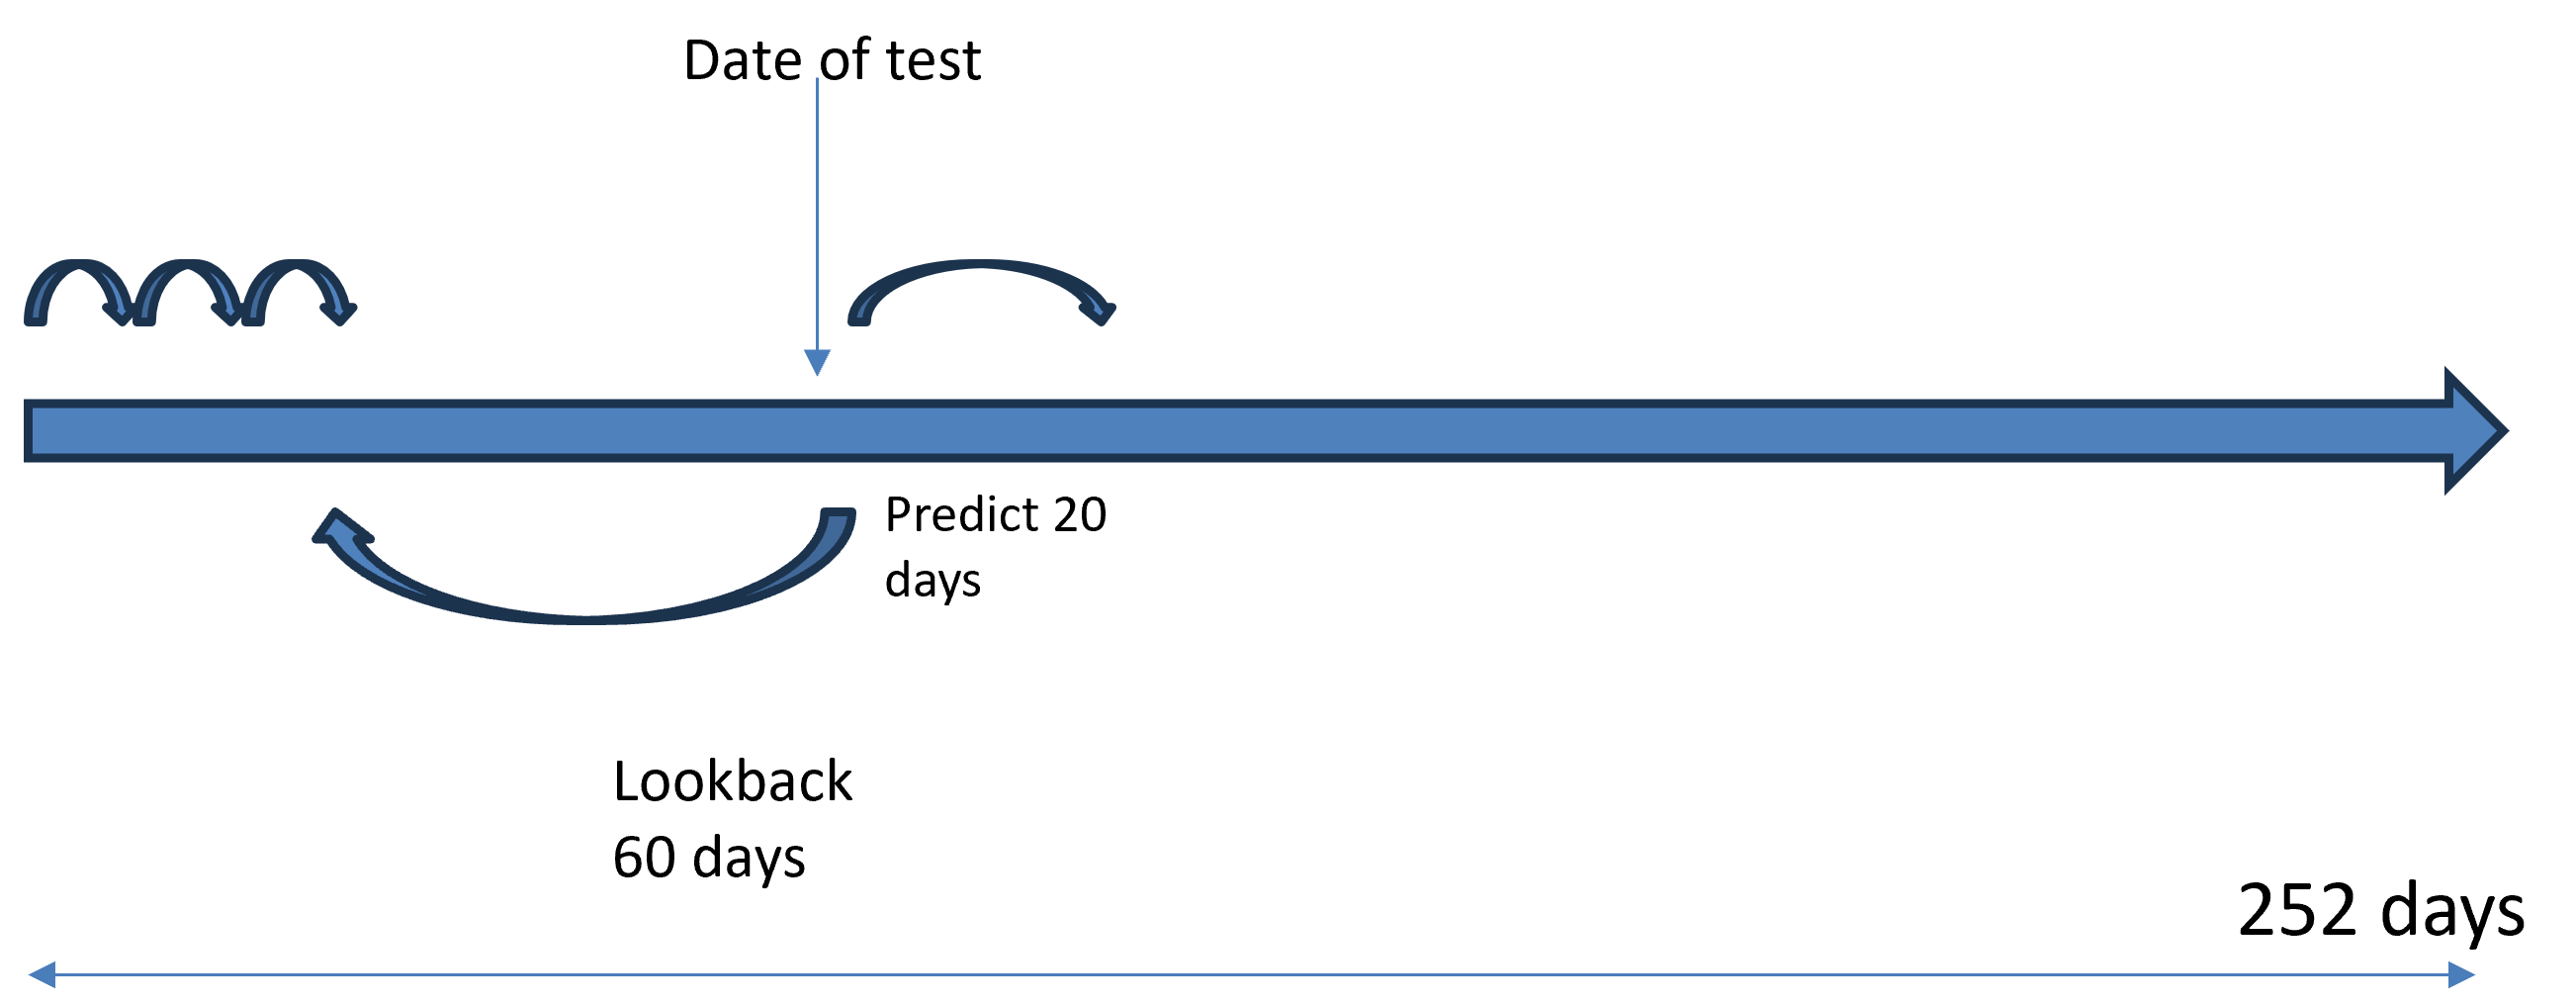


In [14]:
# ----------------------------
# 6. Apply transaction costs
# ----------------------------
weight_change = weights.diff().abs().sum(axis=1)
daily_returns = (weights * returns).sum(axis=1)
daily_returns = daily_returns - weight_change * transaction_cost

### Portfolio Backtest Results

Note the backtest results are based on daily returns, although rebalancing is done monthly. This means the returns are not all realised. (but unrealised)

C:\Users\erict\anaconda3\envs\ml310\lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '51.797%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2023-01-03
End date,2025-11-28
Total months,34
,Backtest
Annual return,51.797%
Cumulative returns,235.03%
Annual volatility,23.558%
Sharpe ratio,1.89
Calmar ratio,1.85
Stability,0.67
Max drawdown,-28.037%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,28.04,2024-06-14,2024-10-23,2024-12-06,126
1,10.60,2025-02-28,2025-03-10,2025-03-24,17
2,9.62,2025-05-27,2025-06-06,2025-06-23,20
3,8.24,2025-06-23,2025-07-02,2025-08-07,34
4,6.61,2025-04-09,2025-04-21,2025-04-25,13


C:\Users\erict\anaconda3\envs\ml310\lib\site-packages\pyfolio\plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])
C:\Users\erict\anaconda3\envs\ml310\lib\site-packages\pyfolio\tears.py:1005: UserWarning: Passed returns do not overlap with anyinteresting times.
  warnings.warn(


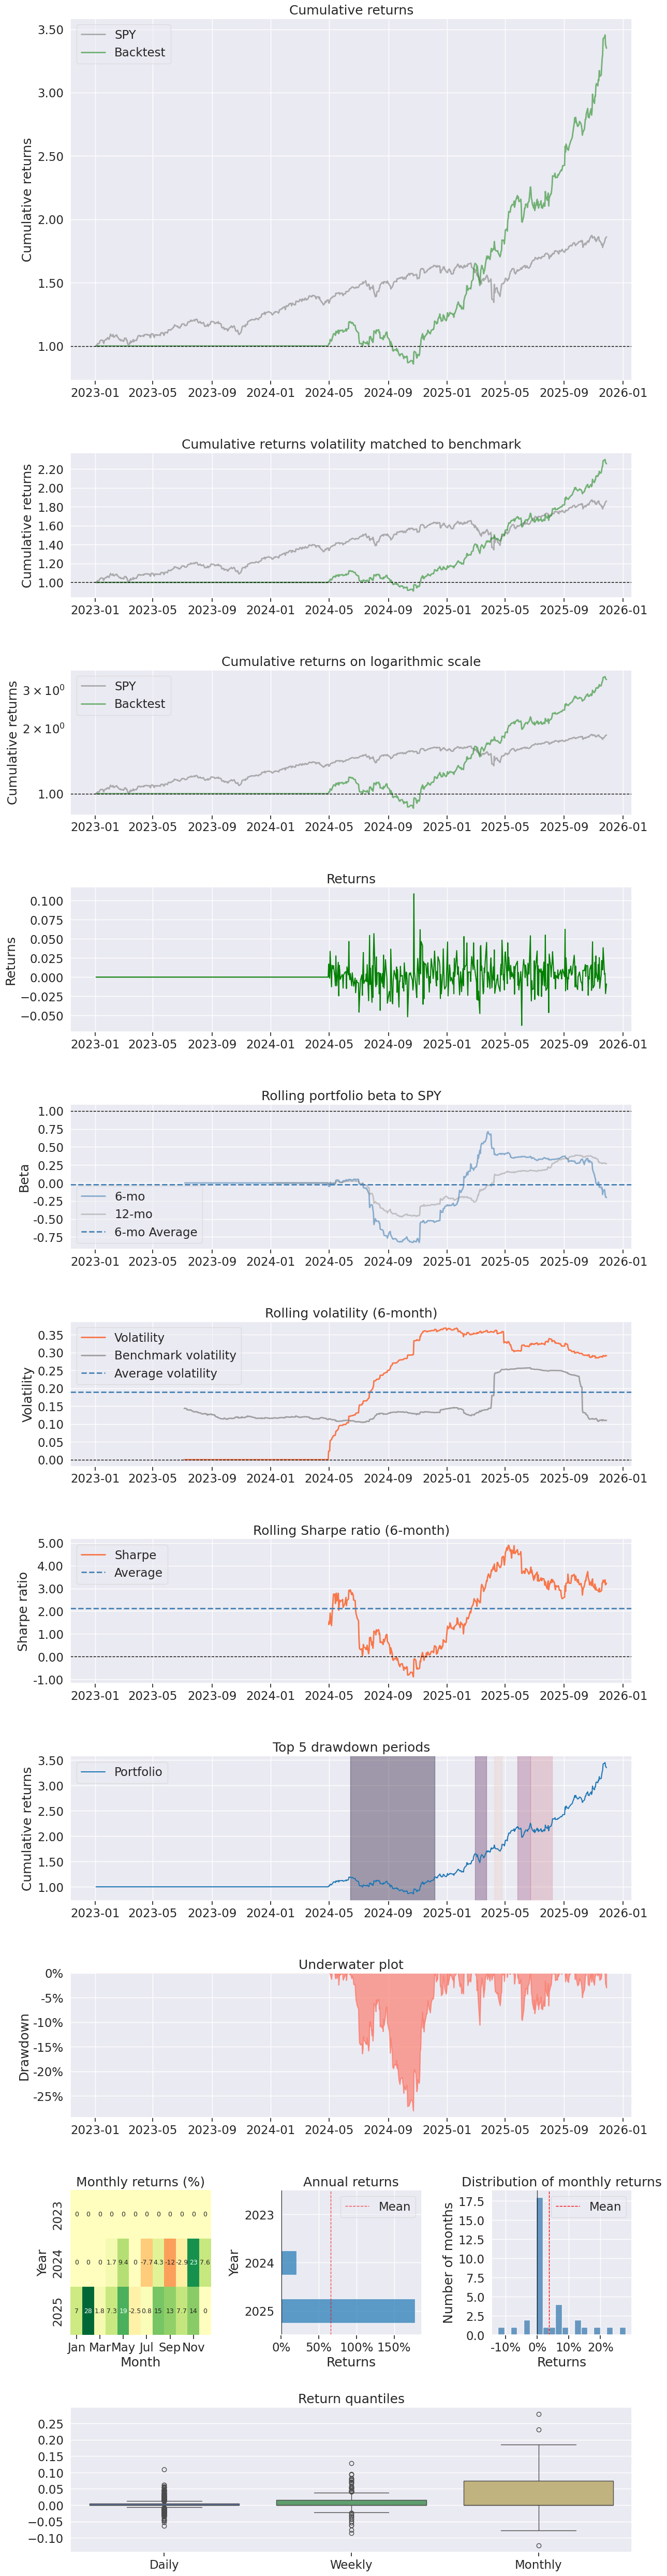

In [16]:
# ----------------------------
# 7. PyFolio analysis
# ----------------------------
# remove the initial 60 days lookback period
daily_returns = daily_returns.replace([np.inf, -np.inf], np.nan).dropna()
pf.create_full_tear_sheet(daily_returns.squeeze(), benchmark_rets=benchmark.squeeze())


### Comments on strategy
- The strategy outperformed the S\&P 500 index over the whole period. Although it must be noted that most of the gains occured in the year 2025.
- DUring the second half of 2024, the strategy did not do well, and fell almost 28% which took almost 4-5 months to recover. 

### Exercise
- As part of the exercise, how will you improve the strategy?
    - Use more stocks
    - Do over a longer period of time for more robustness in results
    - Use another ML method.
    - Use a more stringent filter (with more stocks availability)
    - Use only long strategy (stocks) as a constraint.
    - Use other features (fundamentals eg) Note though these data available on a quarterly basis. 
